# Plots that illustrate the performance of the Agent across Seeds and different theta conditions

### Import packages and Tables

In [2]:
# imports
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('/Users/liviastein/STDP_Theta-1/ResultPipelines/plot_style.mplstyle')

summary_dir = Path("/Users/liviastein/STDP_Theta-1/ResultPipelines/summary_tables")

# files contain condition, seed, number episodes, counts, percentage correct, duration to goal
files = {
    "clean_theta": summary_dir / "clean_theta_seed_summary_table.csv",
    "scrambled_0.2": summary_dir / "ScrTheta_0.2_seed_summary_table.csv",
    "scrambled_0.4": summary_dir / "ScrTheta_0.4_seed_summary_table.csv",
    "scrambled_0.6": summary_dir / "ScrTheta_0.6_seed_summary_table.csv",
    "scrambled_0.8": summary_dir / "ScrTheta_0.8_seed_summary_table.csv",
    "scrambled_1.0": summary_dir / "ScrTheta_seed_summary_table.csv",
}

summary_frames = []
for condition_name, path in files.items():
    df = pd.read_csv(path)
    # Rename theta_condition values to standardized names
    df["theta_condition"] = condition_name
    summary_frames.append(df)

all_seed_summary = pd.concat(summary_frames, ignore_index=True)
all_seed_summary

,theta_condition,seed,total_episodes,reached_goal,wrong_arm,timeouts,percentage_correct,average_time_to_goal
0,clean_theta,0,10,7,1,2,0.7,49.434286
1,clean_theta,2,10,7,2,1,0.7,46.965714
2,clean_theta,4,10,7,2,1,0.7,53.964286
3,clean_theta,6,10,9,1,0,0.9,48.920000
4,clean_theta,42,10,8,2,0,0.8,45.797500
5,scrambled_0.2,0,10,4,1,5,0.4,57.855000
6,scrambled_0.2,2,10,1,2,7,0.1,61.720000
7,scrambled_0.2,4,10,1,0,9,0.1,73.970000
8,scrambled_0.2,6,10,3,1,6,0.3,55.073333
9,scrambled_0.2,42,10,3,0,7,0.3,65.960000


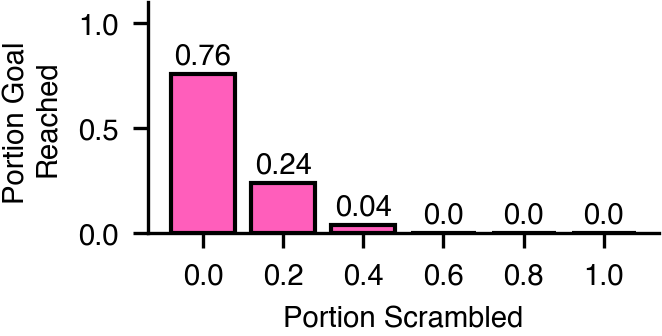

In [19]:
#plt.style.use("seaborn-v0_8-whitegrid")
plt.style.use('/Users/liviastein/STDP_Theta-1/ResultPipelines/plot_style.mplstyle')
Livi_palette1 = ['#ff66c4', '#2AF5FF', '#531CB3', '#0CBABA', '#2191FB', '#FFB800', '#FF5733']
#define new palette with labels for each hex colour, so colours can be called by label instead of index
Livi_palette = {
    "türkis": '#66dfd8',
    "lBlue": '#1097d3',
    "dViolet": '#5e17eb',
    "lpurple": '#8c52ff',
    "altRosa": '#cb6ce6',
    "lRosa": '#e2a9f1',
    "pink": '#ff5ebb'
}

# Order conditions
condition_order = ["clean_theta", "scrambled_0.2", "scrambled_0.4", "scrambled_0.6", "scrambled_0.8", "scrambled_1.0"]

# Calculate mean percentage correct per condition
percentage_by_condition = all_seed_summary.groupby("theta_condition")["percentage_correct"].mean()
percentage_by_condition = percentage_by_condition.reindex(condition_order)

# Create bar plot with colors from palette
fig, axes = plt.subplots(figsize=(2.2, 1.0))
#colors = [Livi_palette[i % len(Livi_palette)] for i in range(len(percentage_by_condition))]
#ax.bar(range(len(percentage_by_condition)), percentage_by_condition.values, color=colors, edgecolor='#531CB3', linewidth=1.5)
axes.bar(range(len(percentage_by_condition)), percentage_by_condition.values, color= Livi_palette["pink"], edgecolor="black")
axes.labelweight = 'bold'
# Set x-axis labels
axes.set_xticks(range(len(percentage_by_condition)))
x_labels = ["0.0", "0.2", "0.4", "0.6", "0.8", "1.0"]
axes.set_xticklabels(x_labels, rotation=0, ha='center')

# Set labels and title
axes.set_ylabel("Portion Goal \nReached", fontweight='bold') 
axes.set_xlabel("Portion Scrambled", fontweight='bold')
#plt.suptitle("Performance Across Theta Conditions", fontsize=24, fontweight='bold')
#ax.set_title("Performance Across 5 Seeds with 10 Episodes Each", fontsize=16, fontstyle='italic')
axes.set_ylim(0, 1.1)

#axes.spines['top'].set_visible(True)

# Add value labels on bars
for i, v in enumerate(percentage_by_condition.values):
    axes.text(i, v + 0.02, f'{v}', ha='center', va='bottom')

plt.savefig("/Users/liviastein/STDP_Theta-1/Final_Figures/PortionGoalReached.pdf", transparent=True)
#plt.tight_layout()
plt.show()

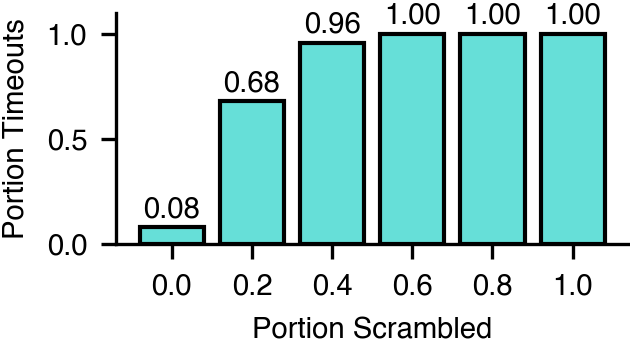

In [18]:
#plt.style.use("seaborn-v0_8-whitegrid")
Livi_palette1 = ['#ff66c4', '#2AF5FF', '#531CB3', '#0CBABA', '#2191FB', '#FFB800', '#FF5733']

# Order conditions
condition_order = ["clean_theta", "scrambled_0.2", "scrambled_0.4", "scrambled_0.6", "scrambled_0.8", "scrambled_1.0"]

# Calculate percentage of timeouts per seed, then mean across seeds per condition
all_seed_summary["timeout_percentage"] = all_seed_summary["timeouts"] / all_seed_summary["total_episodes"]
timeouts_percentage_by_condition = all_seed_summary.groupby("theta_condition")["timeout_percentage"].mean()
timeouts_percentage_by_condition = timeouts_percentage_by_condition.reindex(condition_order)

# Create bar plot with colors from palette
figure, axes = plt.subplots(figsize=(2.2, 1.0))
#figure.facecolor = None
#axes.facecolor = None
#colors = [Livi_palette[i % len(Livi_palette)] for i in range(len(timeouts_percentage_by_condition))]
axes.bar(range(len(timeouts_percentage_by_condition)), timeouts_percentage_by_condition.values, color=Livi_palette["türkis"], edgecolor='black')

# Set x-axis labels
axes.set_xticks(range(len(timeouts_percentage_by_condition)))
x_labels = ["0.0", "0.2", "0.4", "0.6", "0.8", "1.0"]
axes.set_xticklabels(x_labels, rotation=0, ha='center')

# Set labels and title
axes.set_ylabel("Portion Timeouts", fontweight='bold')
axes.set_xlabel("Portion Scrambled")
#plt.suptitle("Timeouts Across Theta Conditions", fontsize=24, fontweight='bold')
#axes.set_title("Timeouts Across 5 Seeds with 10 Episodes Each", fontsize=16, fontstyle='italic')
axes.set_ylim(0, 1.1)

# Add value labels on bars
for i, v in enumerate(timeouts_percentage_by_condition.values):
    axes.text(i, v + 0.02, f'{v:.2f}', ha='center', va='bottom') # with rounded values

# save figure
plt.savefig("/Users/liviastein/STDP_Theta-1/Final_Figures/PortionTimeouts1.pdf", transparent=True)

#plt.tight_layout()
plt.show()

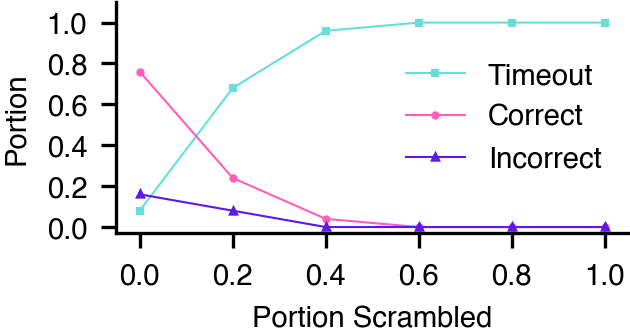

In [16]:
#plt.style.use("seaborn-v0_8-whitegrid")
Livi_palette1 = ['#ff66c4', '#2AF5FF', '#531CB3', '#0CBABA', '#2191FB', '#FFB800', '#FF5733']
Livi_palette = {
    "türkis": '#66dfd8',
    "lBlue": '#1097d3',
    "dViolet": '#5e17eb',
    "lpurple": '#8c52ff',
    "altRosa": '#cb6ce6',
    "lRosa": '#e2a9f1',
    "pink": '#ff5ebb'
}

# Order conditions
condition_order = ["clean_theta", "scrambled_0.2", "scrambled_0.4", "scrambled_0.6", "scrambled_0.8", "scrambled_1.0"]
x_labels = ["0.0", "0.2", "0.4", "0.6", "0.8", "1.0"]
x_positions = range(len(condition_order))

# Calculate percentages per condition
all_seed_summary["timeout_percentage"] = all_seed_summary["timeouts"] / all_seed_summary["total_episodes"]
all_seed_summary["wrong_arm_percentage"] = all_seed_summary["wrong_arm"] / all_seed_summary["total_episodes"]

goal_reached_by_condition = all_seed_summary.groupby("theta_condition")["percentage_correct"].mean().reindex(condition_order)
timeout_pct_by_condition = all_seed_summary.groupby("theta_condition")["timeout_percentage"].mean().reindex(condition_order)
wrong_arm_pct_by_condition = all_seed_summary.groupby("theta_condition")["wrong_arm_percentage"].mean().reindex(condition_order)

# Create line plot
fig, ax = plt.subplots(figsize=(2.2, 1.0))
ax.plot(x_positions, timeout_pct_by_condition.values, marker='s' , linewidth= 0.5, label='Timeout', color=Livi_palette['türkis'])
ax.plot(x_positions, goal_reached_by_condition.values, marker='o', linewidth= 0.5, label='Correct', color=Livi_palette['pink'])
ax.plot(x_positions, wrong_arm_pct_by_condition.values, marker='^', linewidth= 0.5, label='Incorrect', color=Livi_palette['dViolet'])

# Set x-axis labels
ax.set_xticks(x_positions)
ax.set_xticklabels(x_labels, rotation=0, ha='center')
ax.set_yticks(np.arange(0, 1.1, 0.2))  # Set y-ticks from 0 to 1 with step of 0.2

# Set labels and title
ax.set_ylabel("Portion")
ax.set_xlabel("Portion Scrambled")
#plt.suptitle("Performance Metrics Across Theta Conditions", fontsize=24, fontweight='bold')
#ax.set_title("Percentage Goal Reached, Timeouts, and Wrong Arm Choices", fontsize=16, fontstyle='italic')
ax.set_ylim(-0.03, 1.1)

# Add legend
ax.legend(loc='right', fontsize=7)

# Add grid
#ax.grid(True, alpha=0.3)

# save figure
plt.savefig("/Users/liviastein/STDP_Theta-1/Final_Figures/PerformanceMetricCurves.pdf", transparent=True)

#plt.tight_layout()
plt.show()

### Old/Livi syle plots

In [ ]:
plt.style.use("seaborn-v0_8-whitegrid")
Livi_palette1 = ['#ff66c4', '#2AF5FF', '#531CB3', '#0CBABA', '#2191FB', '#FFB800', '#FF5733']

# Order conditions
condition_order = ["clean_theta", "scrambled_0.2", "scrambled_0.4", "scrambled_0.6", "scrambled_0.8", "scrambled_1.0"]

# Calculate percentage of timeouts per seed, then mean across seeds per condition
all_seed_summary["timeout_percentage"] = all_seed_summary["timeouts"] / all_seed_summary["total_episodes"]
timeouts_percentage_by_condition = all_seed_summary.groupby("theta_condition")["timeout_percentage"].mean()
timeouts_percentage_by_condition = timeouts_percentage_by_condition.reindex(condition_order)

# Create bar plot with colors from palette
fig, ax = plt.subplots(figsize=(10, 6))
#colors = [Livi_palette[i % len(Livi_palette)] for i in range(len(timeouts_percentage_by_condition))]
ax.bar(range(len(timeouts_percentage_by_condition)), timeouts_percentage_by_condition.values, color=Livi_palette["pink"], edgecolor='black', linewidth=1.5)

# Set x-axis labels
ax.set_xticks(range(len(timeouts_percentage_by_condition)))
x_labels = ["0.0", "0.2", "0.4", "0.6", "0.8", "1.0"]
ax.set_xticklabels(x_labels, rotation=0, ha='right', size=7)

# Set labels and title
ax.set_ylabel("Portion Timeouts")
ax.set_xlabel("Portion Scrambled")
#plt.suptitle("Timeouts Across Theta Conditions", fontsize=24, fontweight='bold')
#ax.set_title("Timeouts Across 5 Seeds with 10 Episodes Each", fontsize=16, fontstyle='italic')
ax.set_ylim(0, 1.1)

# Add value labels on bars
for i, v in enumerate(timeouts_percentage_by_condition.values):
    ax.text(i, v + 0.02, f'{v*100:.1f}%', ha='center', va='bottom', fontsize=10)

#plt.tight_layout()
plt.show()